In [174]:
%load_ext autoreload
%autoreload 2

import os
import json
import cv2
import numpy as np
import torch
import glob
import torch.nn as nn

import tqdm # For progress bars

from yolo.yolo import Yolo
from yolo.loss import MultiFactorLoss

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [175]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(device)

mps


In [176]:
class_dict = {
    'Head': 0,
    'RShoulder': 1,
    'LShoulder': 2,
    'LElbow': 3,
    'LWrist': 4,
    'RHip': 5,
    'LHip': 6,
    'LKnee': 7,
    'RKnee': 8,
    'RAnkle': 9,
    'LAnkle': 10,
    'RElbow': 11,
    'RWrist': 12,
    'Neck': 13
}

In [177]:
def Json_to_yolo_formate(json_data, img_width, img_height):
    yolo_data = []
    for shape in json_data['shapes']:
        x1, y1 = shape['points'][0]
        x2, y2 = shape['points'][1]
        x_left = x1 / img_width
        y_top = y1 / img_height
        width = (x2 - x1) / img_width
        height = (y2 - y1) / img_height
        class_id = class_dict[shape['label']]
        yolo_data.append([class_id, x_left, y_top, width, height])
    return yolo_data

def save_yolo_formate(json_data):
    image_name = json_data['imagePath'].split('.')[0]
    image_path = f"./dataset/{image_name}.png"
#     print(image_path)
    img = cv2.imread(image_path)
    h, w, _ = img.shape
    yolo_data = Json_to_yolo_formate(json_data, w, h)
    directory = './dataset/annotation_percentage/'
    if not os.path.exists(directory):
        os.makedirs(directory)
    with open (f'{directory}{image_name}.txt', 'w') as f:
        for data in yolo_data:
            f.write(' '.join(map(str, data)) + '\n')

In [178]:
import matplotlib.pyplot as plt
import pandas as pd
import cv2

normal_size = (128,128)

def load_image(path):
    return cv2.imread(path)

def load_json(path):
    with open(path, 'r') as f:
        return json.load(f)

def crop_image(image, coords):
    x1, y1 = coords[0]
    x2, y2 = coords[1]
    return image[int(y1):int(y2), int(x1):int(x2)]

def show_image_detail(image, json):
    plt.imshow(image)
    fig, axs = plt.subplots(1, len(json['shapes']), figsize=(15, 15))
    for i, shape in enumerate(json['shapes']):
        croped_test_img = crop_image(image, shape['points'])
        croped_test_img = resize_image(croped_test_img)
        print(croped_test_img.shape)
        axs[i].imshow(croped_test_img)
        axs[i].set_title(shape['label'])
    plt.show()

def resize_image(image, size=normal_size):
    return cv2.resize(image, size)

def vaildate_yolo_formate(path):
    imag = cv2.imread(path)
    yolo_path = os.path.join('dataset', 'annotation_percentage', os.path.basename(path).split('.')[0] + '.txt')
    with open(yolo_path, 'r') as boxes:
        for box in boxes:
            box = box.split(' ')
            class_id, x_center, y_center, width, height = map(float, box)
            x1 = int(x_center - width/2)
            y1 = int(y_center - height/2)
            x2 = int(x_center + width/2)
            y2 = int(y_center + height/2)
            cv2.rectangle(imag, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(imag, str(int(class_id)), (x1, y1), cv2.FONT_HERSHEY_SIMPLEX, 5, (0, 0, 255), 5)
    imag = cv2.cvtColor(imag, cv2.COLOR_BGR2RGB)
    plt.imshow(imag)
    plt.show()

In [179]:
# json_paths = glob.glob('dataset/*.json')
# for json_path in tqdm.tqdm(json_paths):
#     json_data = load_json(json_path)
#     save_yolo_formate(json_data)

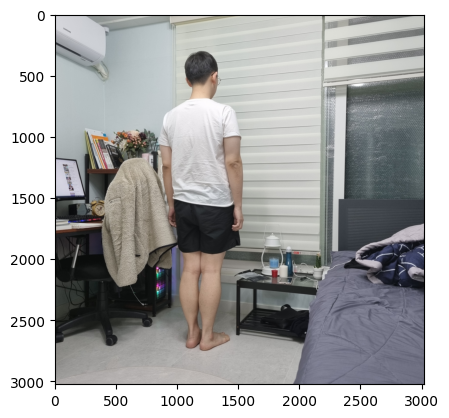

In [180]:
vaildate_yolo_formate('dataset/stand_b_74.png')

In [181]:
def iou(boxes1, boxes2): # box = [x_center, y_center, width, height]
    ious = []
    for box1, box2 in zip(boxes1, boxes2):
        x11, y11, x12, y12 = box1[0] - box1[2]/2, box1[1] - box1[3]/2, box1[0]  + box1[2]/2, box1[1] + box1[3]/2
        x21, y21, x22, y22 = box2[0] - box2[2]/2, box2[1] - box2[3]/2, box2[0]  + box2[2]/2, box2[1] + box2[3]/2

        x_inter1, y_inter1 = max(x11, x21), max(y11, y21)
        x_inter2, t_inter2 = min(x12, x22), min(y12, y22)

        intersection = abs(x_inter2 - x_inter1) * abs(y_inter1 - t_inter2)

        box1_area, box2_area = box1[2] * box1[3], box2[2] * box2[3]
        ious.append(intersection / (box1_area + box2_area - intersection))
    return ious

box1 = [[1, 1, 2, 2], [1, 1, 2, 2]]
box2 = [[2, 1, 2, 2], [3,1,2,2]]
test = iou(box1, box2)
print(test)
    

[0.3333333333333333, 0.0]


In [182]:
box1 = [1,1,2,2]
box2 = [2,1,2,2]
print(iou([box1], [box2]))

[0.3333333333333333]


In [183]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import glob
class backDataset(Dataset):
    def __init__(self, transform=None, anchor_boxes = None):
        self.img_paths = glob.glob('dataset/*.png')
        self.transform = transform
        self.anchor_boxes = anchor_boxes * (416/1920)
    def __len__(self):
        return len(self.img_paths)
    def __getitem__(self, idx):
        img = cv2.imread(self.img_paths[idx])
        original_h, original_w = img.shape[:2]
        normalize = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((416, 416)),
            transforms.ToTensor()
        ])
        with open(os.path.join('dataset', 'annotation_percentage', os.path.basename(self.img_paths[idx]).replace('.png', '.txt'))) as f:
            all_boxes = []
            for line in f.readlines():
                class_id, px, py, pw, ph = map(float, line.strip().split(' ')) # class_id, % x, % y, % w, % h
                
                boxes = []
                for scale in [13, 26, 52]:
                    new_box = torch.zeros(25) # create tensor with 4 + 1 + 14 length + 2 (for px, py)

                    # Assign basic values that no need to compute (..., obj, ..., class, ...)
                    new_box[4] = 1  # Automatically at 1.0 because obv. object
                    new_box[int(class_id + 5)] = 1
                    new_box[-2] = pw
                    new_box[-1] = ph

                    # Assign center offset percentage
                    new_box[-4] = px + (pw / 2) # Set x position percentage to gt_bb center
                    new_box[-3] = py + (ph / 2) # Set y position percentage to gt_bb center
                    
                    # Assign raw tw, th offset
                    new_box[[2, 3]] = torch.tensor([pw * scale, ph * scale])
                    
                    # Compute tx, ty based on raw coordinate offset
                    raw_coord = torch.tensor([new_box[-4] * scale, new_box[-3] * scale])
                    cell_coord = raw_coord // 1
                    new_box[[0, 1]] = raw_coord - cell_coord
                    
                    # Get best anchor for this scale                    
                    best_anchor = [None, -1]  # [[anchor_w, anchor_h]_scaled, anchor_iou]
                    for anchor in self.anchor_boxes:
                        anchor_iou = iou([[0, 0, new_box[2], new_box[3]]], [[0, 0] + (anchor / scale).tolist()])
                        if anchor_iou[0] > best_anchor[1]:
                            best_anchor = [anchor / scale, anchor_iou[0]]
                    new_box[[-6, -5]] = best_anchor[0]
                    
                    # Adjust raw tw, th to real tw th
#                     print(new_box[[2, 3]], '|', best_anchor[0], '|', new_box[[2, 3]] / best_anchor[0])
                    new_box[[2, 3]] = new_box[[2, 3]] / best_anchor[0] # This will give the exp(tw) and exp(th) to get from anchor to gt

                    boxes.append(new_box)
                all_boxes.append(torch.stack(boxes))
#                 print(all_boxes[-1])
        img = normalize(img)
        return img, torch.stack(all_boxes)

From the above, the expected output is a size `23` vector that mimics the vector expected from predictions.  

Expected shape is `[num_boxes_img, 3 (num_scales), bounding_box_vector]`. The first two sizes are self explanatory. 
The last size is the `23` size bounding box vector relative to an anchor box that was assigned. The elements are:  
`[tx, ty, exp(tw), exp(th), obj, ...classes probs... x 14, aw, wh, px, py, pw, ph]` such that `px, py`, `pw, ph` are the percentage coordinates to center of cell and w/h of the ground truth bounding box. `aw, ah` is the assigned anchor box's width and height (already scaled) (may remove if not needed). `tx, ty, tw, th` are the absolutes, i.e. `tx` is `tx` away from the left of the cell, `tw` is the width of the bounding box times `tw`.

For extracting information, make sure to use `box[:19]` to not get the last 4 meta data elements (unless needed).

Example:  
`torch.Size([14, 3, 23])`  

This means `14` boxes in img, for each box, there's a size `23` vector for each of the `3` scales. **The scales are already computed, no need to scale again**

In [184]:
def show_img_box(img, data):
    tmp_img = img.permute(1, 2, 0)
    tmp_img = cv2.cvtColor(tmp_img.numpy(), cv2.COLOR_BGR2RGB)
    for box in data:
        class_id = torch.argmax(box[0][5:19])
        box_dim = (box[0][[-2, -1]] * 416)
        x1, y1 = (box[0][[-4, -3]] * 416) - (box_dim / 2) 
        x2, y2 = (box[0][[-4, -3]] * 416) + (box_dim / 2) 
        cv2.rectangle(tmp_img, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
        cv2.putText(tmp_img, str(int(class_id)), (int(x1), int(y1)), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 1)
    plt.imshow(tmp_img)


In [185]:
anchors = torch.tensor([[151.37092679, 151.37092679], [116.1775567, 116.1775567 ], [ 69.10933737,  69.10933737], 
                        [206.27557981, 206.27557981], [257.97346109, 257.97346109]])

In [186]:
test_loader = DataLoader(backDataset(anchor_boxes=anchors), batch_size=1, shuffle=True)

In [187]:
img, data = test_loader.dataset[0]

In [188]:
print(data.shape)
data[0]

torch.Size([10, 3, 25])


tensor([[0.2639, 0.0658, 1.1017, 1.1017, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 1.1518, 1.1518, 0.4818, 0.1589, 0.0976, 0.0976],
        [0.5278, 0.1317, 1.1806, 1.1806, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 2.1498, 2.1498, 0.4818, 0.1589, 0.0976, 0.0976],
        [0.0556, 0.2633, 4.7224, 4.7224, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 1.0749, 1.0749, 0.4818, 0.1589, 0.0976, 0.0976]])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


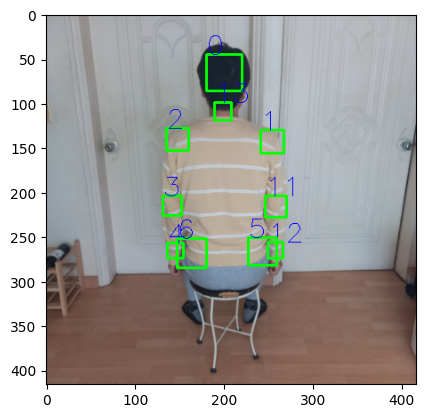

In [189]:
show_img_box(img, data)

In [190]:
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

def collate_fn(batch): # each item in batch is (x, y)
    img = [item[0] for item in batch]
    boxes = [item[1] for item in batch]
    max_boxes = max([len(box) for box in boxes])
    boxes_list_padded = []
    for box in boxes:
        if box.shape[0] < max_boxes:
            box = torch.cat([box, torch.zeros(max_boxes - box.shape[0], box.shape[1], box.shape[2])])
        boxes_list_padded.append(box)
    return torch.stack(img), torch.stack(boxes_list_padded)


dataset = backDataset(anchor_boxes=anchors)
train_size = int(0.7 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=10, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=True, collate_fn=collate_fn)

In [191]:
test_train_img, test_train_data = next(iter(train_loader))
print(test_train_img.shape)
print(test_train_data.shape)

torch.Size([10, 3, 416, 416])
torch.Size([10, 14, 3, 25])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


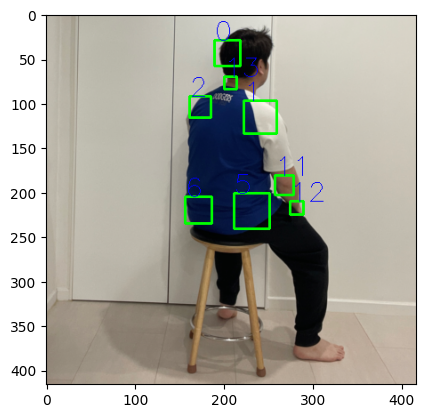

In [192]:
show_img_box(test_train_img[0], test_train_data[0])

# YOLO
Yolov3 (might be easier)
https://blog.paperspace.com/how-to-implement-a-yolo-object-detector-in-pytorch/
https://arxiv.org/abs/1804.02767

In [193]:
tt, td = next(iter(train_loader))

In [194]:
# show_img_box(tt[0], td[0])
# for img, data in zip(tt, td):
#     show_img_box(img, data)

In [195]:
tt.shape

torch.Size([10, 3, 416, 416])

In [196]:
yolo_test = Yolo(14, anchors.shape[0]).to(device)

In [197]:
tt = tt.to(device)
td = td.to(device)
test_result = yolo_test(tt)
# test_result = [result.permute(0, 2, 3, 1) for result in test_result] # need to permute to (x, y, 95) b/c 95 is layers, not prediciton list as wanted

In [198]:
print(test_result[0].shape)
test_layer = test_result[0].permute(0, 3, 1, 2)
test_layer = test_layer.reshape(10,5,19,13, 13)
test_layer2 = test_layer[:, :, 0, :,:]
print(test_layer2.shape)


torch.Size([10, 95, 13, 13])
torch.Size([10, 5, 13, 13])


In [199]:
criterion = MultiFactorLoss(5, batch_avg=True)
criterion(anchors, td, test_result).item()

1113.8260498046875

In [200]:
# def train(model, optimizer, loss_fn, epochs=10):
#     model = model.to(device=device)
#     for epoch in tqdm.tqdm(range(epochs)):
#         for i, (x, ground_truths) in enumerate(train_loader):
#             x = x.to(device)
#             ground_truths = ground_truths.to(device)
            
#             model.train()
#             y = model(x)
#             loss = loss_fn(anchors, ground_truths, y)
            
#             optimizer.zero_grad()
            
#             if i % 100 == 0:
#                 print(f'Epoch: {epoch}, Iteration: {i}, loss: {loss}')

#             # Delete stuff to free up resources
#             del x
#             del ground_truths
#             del y
#             del loss

In [201]:
# model = Yolo(14, 5, debug=False)
# optimizer = torch.optim.Adam(params=model.parameters())
# train(model, optimizer, MultiFactorLoss(5, batch_avg=True))

In [202]:
# del model
# del optimizer
# del criterion_fn

In [30]:
import yolo.training as yolo_tv

model = Yolo(14, 5, debug=False)
optimizer = torch.optim.Adam(params=model.parameters())
criterion_fn = MultiFactorLoss(5, batch_avg=True)
criterion_fn.requires_grad = True
for param in model.parameters():
    assert param.requires_grad

try:
    yolo_tv.train(model, optimizer, criterion_fn, train_loader, val_loader, anchors)
except Exception as e: # Try except catch for errors to delete gpu data to free resources
    print(e)
    del model
    del optimizer
    del criterion_fn

Criterion Grad: True



Yolov3 Training:   0%|                                                                                                                             | 0/10 [00:00<?, ?it/s]

113.33883666992188
105.7442626953125
545.3251953125
107.55496978759766
103.63066101074219
103.12850952148438


Invalid SOS parameters for sequential JPEG


-0.05421554297208786 0.202503502368927 3.2668821811676025
107.62102508544922
-0.5238276720046997 0.1489402800798416 3.161949872970581
102.79064178466797
98.72173309326172
102.26895141601562
103.56851959228516
-0.12840217351913452 0.28995275497436523 1.2974627017974854
95.56537628173828
-0.8392958045005798 0.1814132183790207 3.4610328674316406
100.85211944580078
91.25276947021484
-0.30547478795051575 0.12603223323822021 2.0246148109436035
92.02120208740234


...

-313.5194396972656 0.146345317363739 2.6565616130828857
-358.7023010253906 0.1161811426281929 1.614798665046692
-159.95335388183594 0.11896061152219772 3.420659065246582
-372.2089538574219 0.10250610113143921 1.996221899986267
-312.55810546875 0.09579259902238846 1.2971887588500977
-260.0729675292969 0.1842590868473053 2.937558650970459
-280.31304931640625 0.3428783416748047 0.7397163510322571
-217.3539581298828 0.19912414252758026 0.9295586943626404
-310.1357421875 0.09193716198205948 2.3056955337524414
-299.8672790527344 0.13773280382156372 2.289762258529663
-57.412315368652344 0.18784324824810028 2.5729830265045166
-55.82081604003906 0.27634066343307495 2.5205092430114746
-19.564361572265625 0.2505522072315216 2.678964376449585
-79.85962677001953 0.2852182686328888 1.504705786705017
-47.87799835205078 0.21118633449077606 1.4917174577713013
-51.23271942138672 0.2647457420825958 2.042564868927002
-34.505836486816406 0.30965137481689453 0.7588444352149963
-45.26136779785156 0.231718018

Invalid SOS parameters for sequential JPEG


-173.65692138671875 0.11823427677154541 3.222198247909546
-276.5939025878906 0.11362636089324951 1.9811525344848633
-297.0709228515625 0.11239814758300781 1.6889612674713135
-216.03053283691406 0.21890583634376526 1.4640965461730957
-433.87188720703125 0.16218379139900208 1.5382288694381714
-235.5920867919922 0.11235756427049637 2.3766143321990967
-170.5069580078125 0.09644263982772827 2.484276533126831
-136.26773071289062 0.13140733540058136 2.651688814163208
-191.31170654296875 0.12296729534864426 2.2246556282043457
-122.11117553710938 0.20504437386989594 0.8203564882278442
-24.443185806274414 0.25022628903388977 2.7592122554779053
-56.24129104614258 0.27995288372039795 1.215726613998413
-67.78997039794922 0.2339218258857727 1.406638503074646
-25.59720230102539 0.25313255190849304 1.2273297309875488
-38.683570861816406 0.21964259445667267 1.0942732095718384
-20.12485122680664 0.1916435807943344 2.427269458770752
-34.659305572509766 0.2872787415981293 2.3331921100616455
-19.3041877746

Yolov3 Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [21:44<00:00, 130.43s/it]

-391.44952392578125 0.13136525452136993 1.9197666645050049
-306.82293701171875 0.11388721317052841 2.3392529487609863
-65.47875213623047 0.17152094841003418 1.7404776811599731
-45.82532501220703 0.15485097467899323 2.2476301193237305
-1.9230011701583862 0.33560603857040405 1.9928033351898193
-1.6532413959503174 0.29782193899154663 2.112828016281128
Epoch 10/10, Loss: -2428.8506, Val_loss: -2894.1322, Time: 116.86


In [31]:
test_result[0].shape

torch.Size([10, 95, 13, 13])

Expected prediction structure `[tx, ty, tw, tl, obj, c1, c2, ..., c14]`

In [32]:
td[4]

tensor([[[0.2491, 0.3575, 0.7687,  ..., 0.1044, 0.0681, 0.0681],
         [0.4983, 0.7151, 1.0301,  ..., 0.1044, 0.0681, 0.0681],
         [0.9966, 0.4302, 3.2947,  ..., 0.1044, 0.0681, 0.0681]],

        [[0.2418, 0.6305, 0.3971,  ..., 0.1254, 0.0352, 0.0352],
         [0.4835, 0.2611, 0.9450,  ..., 0.1254, 0.0352, 0.0352],
         [0.9671, 0.5221, 1.7023,  ..., 0.1254, 0.0352, 0.0352]],

        [[0.9506, 0.3019, 0.6149,  ..., 0.1771, 0.0545, 0.0545],
         [0.9012, 0.6039, 1.1230,  ..., 0.1771, 0.0545, 0.0545],
         [0.8025, 0.2077, 2.6358,  ..., 0.1771, 0.0545, 0.0545]],

        ...,

        [[0.0755, 0.7435, 1.0505,  ..., 0.5187, 0.0931, 0.0931],
         [0.1510, 0.4869, 1.1257,  ..., 0.5187, 0.0931, 0.0931],
         [0.3019, 0.9739, 4.5027,  ..., 0.5187, 0.0931, 0.0931]],

        [[0.3417, 0.5692, 0.7815,  ..., 0.7361, 0.0692, 0.0692],
         [0.6833, 0.1385, 1.0473,  ..., 0.7361, 0.0692, 0.0692],
         [0.3666, 0.2770, 3.3496,  ..., 0.7361, 0.0692, 0.0692]],

 

In [33]:
# bounding_loss(ab, td[4], test_result)

In [34]:
a = torch.randn(5)
b = torch.randn(5)
c = torch.randn(5)

torch.stack([a, b, c])

tensor([[ 0.9683,  0.7852, -0.7203,  1.8005, -1.4481],
        [ 1.2341,  0.2110,  0.8851, -0.9815, -0.1140],
        [-0.4589,  3.3862,  0.7459,  0.1412, -0.5565]])

In [35]:
print(a, b, c)

tensor([ 0.9683,  0.7852, -0.7203,  1.8005, -1.4481]) tensor([ 1.2341,  0.2110,  0.8851, -0.9815, -0.1140]) tensor([-0.4589,  3.3862,  0.7459,  0.1412, -0.5565])


In [36]:
# bounding_loss(ab, td[4], test_result)

In [37]:
a = torch.randn(5)
b = torch.randn(5)
c = torch.randn(5)

torch.stack([a, b, c])

tensor([[-1.1452, -0.7784, -0.1326,  1.1687, -0.3612],
        [ 0.8111, -0.9379,  3.6390, -0.8327, -1.2982],
        [-2.0314,  1.1260, -0.7949, -0.9644,  1.9243]])

In [38]:
print(a, b, c)

tensor([-1.1452, -0.7784, -0.1326,  1.1687, -0.3612]) tensor([ 0.8111, -0.9379,  3.6390, -0.8327, -1.2982]) tensor([-2.0314,  1.1260, -0.7949, -0.9644,  1.9243])


In [39]:
# def function_to_grid(ground_truths,S):
#     output_size = [13, 26, 52]
#     S_dim = output_size[S]
#     return torch.round(ground_truths[:,:,S,-4:-2] * S_dim).long()

    
# def one_hot_coordinate(ground_truths,S):
#     output_size = [13, 26, 52]
#     S_dim = output_size[S]
#     grid_have_stuff = function_to_grid(ground_truths,S)
#     one_hot = torch.zeros(10,S_dim,S_dim)
#     for i in range(10):
#         one_hot[i,grid_have_stuff[i,:,1],grid_have_stuff[i,:,0]] = 1
#     return one_hot

# import torch
# import torch.nn.functional as F

# def obj_loss(pred, target):
#     print(pred.shape, target.shape)
#     pred0 = pred[0][:,:,:,4].reshape(-1)
#     pred1 = pred[1][:,:,:,4].reshape(-1)
#     pred2 = pred[2][:,:,:,4].reshape(-1)
#     OH_gt0 = one_hot_coordinate(target,0).reshape(-1)
#     OH_gt1 = one_hot_coordinate(target,1).reshape(-1)
#     OH_gt2 = one_hot_coordinate(target,2).reshape(-1)
    
#     # Apply sigmoid activation to the raw predictions
#     pred0 = torch.sigmoid(pred0)
#     pred1 = torch.sigmoid(pred1)
#     pred2 = torch.sigmoid(pred2)
    
#     # Compute the binary cross entropy loss
#     loss = F.binary_cross_entropy(pred0, OH_gt0)
#     loss += F.binary_cross_entropy(pred1, OH_gt1)
#     loss += F.binary_cross_entropy(pred2, OH_gt2)
    
#     return loss


# # loss = obj_loss(test_result, td)
# # print(loss)

In [203]:
# ground_truth: torch.Size([13, 25]) where 13 is the number of cells (that have a object=1) and 25 is the vector, and all that stuff
# pred_y: torch.Size([5, 19, 13]) where 5 is the number of anchor box predictions, 19 is the vector, and 13 is the number of cells (that have a object=1)
gt = torch.randn(13, 25)
gt[:, -4:-2] = torch.rand(13, 2) *0.75

In [204]:
def CELoss (pred, target):
    # pred = (1, 14) that is in raw form
    # target = (1) that is the class id
    return F.cross_entropy(pred, target)
def class_loss(pred, target, scale):
    # pred = (5, 21, 13)
    # target = (13, 25)
    # pred_coord = (13, 2)

    target_coord = function_to_grid(target, scale) # (13, 2)
    target_class = target[:, 5:19] # (13, 14)
    target_class_id = torch.argmax(target_class, dim=1) # (13)
    pred_permute = pred.permute(0, 2, 1) # (5, 13, 21)
    predictions = pred_permute[:, :, 5:19] # (5, 13, 14)
    loss = 0
    loss += CELoss(predictions[0], target_class_id)
    loss += CELoss(predictions[1], target_class_id)
    loss += CELoss(predictions[2], target_class_id)
    loss += CELoss(predictions[3], target_class_id)
    loss += CELoss(predictions[4], target_class_id)
    return loss



In [245]:
def function_to_grid(ground_truths,S):
    output_size = [13, 26, 52]
    S_dim = output_size[S]
    return torch.round(ground_truths[:,:,S,-4:-2] * S_dim).long()

    
def one_hot_coordinate(ground_truths,S):
    output_size = [13, 26, 52]
    S_dim = output_size[S]
    grid_have_stuff = function_to_grid(ground_truths,S)
    # print(grid_have_stuff.shape)
    one_hot = torch.zeros(10,S_dim,S_dim)
    for i in range(10):
        one_hot[i,grid_have_stuff[i,:,1],grid_have_stuff[i,:,0]] = 1
    # print("one_hot shape", one_hot.shape)
    return one_hot

import torch
import torch.nn.functional as F

def obj_loss(pred, target):
    #Change hyperparameter here
    OBJLOSS_WEIGHT = 1
    NOOBJLOSS_WEIGHT = 0.5
    print(pred[0].shape, target.shape)
    pred0 = pred[0].reshape(10, 13, 13, -1, 19).to(device) 
    pred1 = pred[1].reshape(10, 26, 26, -1, 19).to(device)
    pred2 = pred[2].reshape(10, 52, 52, -1, 19).to(device)

    pred0 = pred0[:,:,:,:,4].to(device) # (10, 13, 13, 5) [B,S,S,A] A:number of anchor boxes
    pred1 = pred1[:,:,:,:,4].to(device)
    pred2 = pred2[:,:,:,:,4].to(device)
    
    

    OH_gt0 = one_hot_coordinate(target,0).to(device)
    OH_gt0_obj = OH_gt0 == 1
    OH_gt0_noobj = OH_gt0 == 0
    OH_gt0 = OH_gt0.unsqueeze(-1).expand(-1, -1, -1, 5).to(device) # (10, 13, 13, 5)
    OH_gt1 = one_hot_coordinate(target,1).to(device)
    OH_gt1_obj = OH_gt1 == 1
    OH_gt1_noobj = OH_gt1 == 0
    OH_gt1 = OH_gt1.unsqueeze(-1).expand(-1,-1,-1,5).to(device)
    OH_gt2 = one_hot_coordinate(target,2).to(device)
    OH_gt2_obj = OH_gt2 == 1
    OH_gt2_noobj = OH_gt2 == 0
    OH_gt2 = OH_gt2.unsqueeze(-1).expand(-1,-1,-1,5).to(device)
#     print(one_hot_coordinate(target,0).reshape(-1).shape)
    
    # Apply sigmoid activation to the raw predictions
    pred0 = torch.sigmoid(pred0)
    pred1 = torch.sigmoid(pred1)
    pred2 = torch.sigmoid(pred2)
    
    # Compute the binary cross entropy loss
    loss0 = F.binary_cross_entropy(pred0, OH_gt0)
    loss1 = F.binary_cross_entropy(pred1, OH_gt1)
    loss2 = F.binary_cross_entropy(pred2, OH_gt2)

    # Compute both obj and noobj loss separately
    loss0 = ((OH_gt0_obj * loss0).sum()) * OBJLOSS_WEIGHT + ((OH_gt0_noobj * loss0).sum()) * NOOBJLOSS_WEIGHT
    loss1 = ((OH_gt1_obj * loss1).sum()) * OBJLOSS_WEIGHT + ((OH_gt1_noobj * loss1).sum()) * NOOBJLOSS_WEIGHT
    loss2 = ((OH_gt2_obj * loss2).sum()) * OBJLOSS_WEIGHT + ((OH_gt2_noobj * loss2).sum()) * NOOBJLOSS_WEIGHT

    return loss0 + loss1 + loss2

loss = obj_loss(test_result, td.to(device))
print(loss)

torch.Size([10, 95, 13, 13]) torch.Size([10, 14, 3, 25])
tensor(13025.0439, device='mps:0', grad_fn=<AddBackward0>)


In [206]:
def function_to_grid(input,S, type='gt'):
    if type == 'gt':
        S_dim = S
        return torch.round(input[:,-4:-2] * S_dim).long()
    elif type == 'pred':
        S_dim = S
        return torch.round(input[:,-2:] * S_dim).long()
    else:
        S_dim = S
        return torch.round(input[:,-2:] * S_dim).long()

def one_hot_coordinate(input, S, type='gt'):
    if type == 'gt':
        S_dim = S
        grid_have_stuff = function_to_grid(input, S, type)
        one_hot = torch.zeros(S_dim, S_dim)
        one_hot[grid_have_stuff[:,1], grid_have_stuff[:,0]] = 1
        return one_hot
    else:
        #input = pred.shape = [13, 2]
        S_dim = S
        grid_have_stuff = function_to_grid(input, S, type)
        one_hot = torch.zeros(S_dim, S_dim)
        one_hot[grid_have_stuff[:,1], grid_have_stuff[:,0]] = 1
        return one_hot

def ObjDiceLoss(target_mask, pred_mask):
    smooth = 1e-6
    intersection = (target_mask * pred_mask).sum() + smooth
    union = target_mask.sum() + pred_mask.sum() + smooth
    Dice_score = 2 * intersection / union
    loss = 1 - Dice_score
    return loss

def ObjLoss(target, pre_coord, scale):
    # pred = torch.randn(5, 19, 13)
    # coord = torch.randn(13,2)
    # target = torch.randn(13, 25)
    loss = 0
    pred_OH = torch.zeros(scale, scale)
    pred_OH[pre_coord[:,1], pre_coord[:,0]] = 1
    print(pred_OH.shape)
    pred_OH = pred_OH.view(-1)
    target_OH = torch.zeros(scale, scale)
    target_OH = one_hot_coordinate(target, scale).view(-1)
    loss = F.binary_cross_entropy(pred_OH, target_OH)
    return loss

In [207]:
criterion = MultiFactorLoss(5, batch_avg=True)
criterion(anchors, td, test_result)

tensor(1113.8260, grad_fn=<AddBackward0>)

In [208]:
td.shape

torch.Size([10, 14, 3, 25])

In [209]:
def merge_bbox(results):
    all_imgs = []
    for scale, img_bbs in zip([13, 26, 52], results):
        upscaled_imgs = []
        for img in img_bbs:
            img = torch.stack(torch.split(img, 19, dim=0))
#             img = img.permute(0, 2, 3, 1)
            test = img[:, 4]
            print(img.shape)
            print(test.shape)
            valid_cells = torch.sigmoid(img[:, 4, :, :]) > 0.75
            valid_mask = valid_cells.unsqueeze(1).expand(-1, img.shape[1], -1, -1)
            print(valid_cells.shape)
            print(valid_mask.shape)
            print(img[valid_mask].view(-1, 19).shape)
#             valid_indices = 
            print(img[valid_cells])
#             print(img[img[:,4,:,:] > 0.5].shape)
            return

In [210]:
test_result[0].shape


torch.Size([10, 95, 13, 13])

In [211]:
merge_bbox(test_result)

torch.Size([5, 19, 13, 13])
torch.Size([5, 13, 13])
torch.Size([5, 13, 13])
torch.Size([5, 19, 13, 13])
torch.Size([9, 19])


IndexError: The shape of the mask [5, 13, 13] at index 1 does not match the shape of the indexed tensor [5, 19, 13, 13] at index 1

In [212]:
td[0].shape

torch.Size([14, 3, 25])

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [49]:
tt, td = next(iter(train_loader))
tt = tt.to(device)
test_result = model(tt)

torch.Size([10, 95, 13, 13])
tensor([0.0068, 0.0068])
tensor([1.0249, 1.0249])
torch.Size([10, 5, 19, 13, 13])
torch.Size([10, 13, 13, 5, 19])
torch.Size([10, 13, 13, 19])
0.03125
new box
[0 0] [0.49671793 0.50931805]
new box
[0 1] [0.50284   0.5065449]
new box
[0 3] [0.49910942 0.5045344 ]
new box
[0 4] [0.4957948 0.503077 ]
new box
[0 5] [0.49360955 0.49675462]
new box
[0 6] [0.45205045 0.47050616]
new box
[0 7] [0.486302 0.470339]
new box
[0 8] [0.4940689  0.49628058]
new box
[0 9] [0.5011098 0.5030119]
new box
[ 0 10] [0.49914452 0.5014835 ]
new box
[ 0 12] [0.5011635 0.5016998]
new box
[1 0] [0.4977195  0.51838416]
new box
[1 1] [0.4954029  0.51950884]
new box
[1 2] [0.4976189  0.50550324]
new box
[1 3] [0.48699695 0.49293476]
new box
[1 4] [0.47813827 0.4741702 ]
new box
[1 5] [0.45629394 0.4730431 ]
new box
[1 6] [0.4400151  0.44411117]
new box
[1 7] [0.6881787  0.43724972]
new box
[1 8] [0.52378166 0.49055153]
new box
[1 9] [0.49681252 0.5039875 ]
new box
[ 1 10] [0.49114883 0.

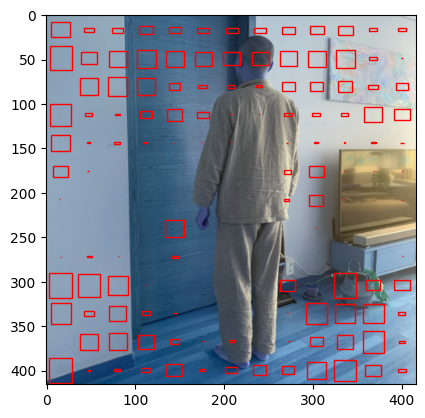

In [59]:
import matplotlib.patches as patches
# first_anchor_box = torch.Tensor([151.37092679, 151.37092679])
# anchors_size = torch.Tensor([1920.0, 1920.0])
# grid_size = torch.Tensor([13, 13])
# anchors_yolo = first_anchor_box / (anchors_size / grid_size)
# print(anchors_yolo)
# test_result_reshape = test_result[0].reshape(10, 5, 19, 13, 13)
# print(test_result_reshape.shape)
# reshape_test = test_result[0].reshape(10, 13, 13, 5, 19) # (10, 13, 13, 5, 19)
# output = reshape_test[:,:,:,0,:] # (10, 13, 13, 19)
# box_xy = output[..., :2] # (10, 13, 13, 2)
# box_wh = output[..., 2:4].cpu() # (10, 13, 13, 2)
# box_wh = box_wh.detach().cpu()
# box_wh = np.exp(box_wh) * anchors_yolo
# box_xy = box_xy.cpu()
# box_xy = box_xy - box_wh / 2
# box_xy = box_xy.detach().numpy()
# box_xy *= (416, 416)
# box_wh = box_wh.cpu()
# box_xy = (box_xy[0])
# box_wh = box_wh[0] * 416
# fig,ax = plt.subplots(1)
# ax.imshow(tt[0].cpu().permute(1, 2, 0))
# for i in range(13):
#     for j in range(13):
#         if output[0, i, j, 4] > 0.5:
#             print(sigmoid(box_xy[i, j]), box_wh[i, j])
#             box = patches.Rectangle((box_xy[i, j, 0], box_xy[i, j, 1]), box_wh[i, j, 0], box_wh[i, j, 1], linewidth=1, edgecolor='r', facecolor='none')
#             ax.add_patch(box)

# print(box_xy.shape)
# print(box_wh.shape)
def plot_pic_with_box(img, pred, Scale, imgIdx,anchorIdx=0, img_size=416, threshold=0.5):
    anchors = torch.tensor([[151.37092679, 151.37092679], [116.1775567, 116.1775567 ], [ 69.10933737,  69.10933737], 
                        [206.27557981, 206.27557981], [257.97346109, 257.97346109]]).cpu()
    anchors_size = anchors[anchorIdx]
    grid_size = torch.tensor([Scale, Scale]).cpu()
    anchors_dim = torch.tensor([1920, 1920]).cpu()
    print(pred.shape)
    print(grid_size / anchors_dim)
    anchors_yolo = anchors_size * (grid_size / anchors_dim).cpu()
    
    # Prediction Processing
    print(anchors_yolo)
    pred_reshape = pred.reshape(10, 5, 19, Scale, Scale).cpu()
    print(pred_reshape.shape)
    pred_reshape = pred_reshape.permute(0, 3, 4, 1, 2).cpu()
    print(pred_reshape.shape)
    output = pred_reshape[:,:,:,anchorIdx,:].cpu() # (10, 13, 13, 19)
    print(output.shape)
    box_xy = output[..., :2].detach().cpu() # (10, 13, 13, 2)
    box_wh = output[..., 2:4].cpu() # (10, 13, 13, 2)
    
    scale_ratio = Scale / img_size # Scaler
    print(scale_ratio)
    box_wh = torch.exp(box_wh).cpu() * anchors_yolo.cpu()
    box_wh = box_wh.detach().cpu()
    box_xy = torch.sigmoid(box_xy).detach().numpy()
#     box_xy *= img_size
#     box_xy = (box_xy - box_wh / 2).cpu()
#     box_xy = box_xy.detach().numpy()
    # print(box_wh)
#     print(box_wh)
#     box_wh /= scale_ratio
#     print(box_wh)
    fig,ax = plt.subplots(1)
    ax.imshow(img.cpu().permute(1, 2, 0))
    for i in range(Scale):
        for j in range(Scale):
            if output[imgIdx, i, j, 4] > threshold:
                print('new box')
                box_truexy = np.array([i, j]) # Get cell in normal image
                print(box_truexy, box_xy[imgIdx, i, j, :])
                box_truexy = (box_truexy + box_xy[imgIdx, i, j, :]) / scale_ratio # Add offset and scale back up to 416      
                box_truewh = np.array([box_wh[imgIdx, i, j, 0], box_wh[imgIdx, i, j, 1]]) / scale_ratio # Get and scale wh back up to 416
#                 print(box_truexy, box_truewh)
                box_truexy -= (box_truewh / 2) # Shift to top left for box drawing
#                 print(box_truexy)
#                 print(box_xy[imgIdx, i, j], box_wh[imgIdx, i, j])
                box = patches.Rectangle((box_truexy[0], box_truexy[1]), box_truewh[0], box_truewh[1], linewidth=1, edgecolor='r', facecolor='none')

#                 box = patches.Rectangle((box_xy[imgIdx, i, j, 0], box_xy[imgIdx, i, j, 1]), box_wh[imgIdx, i, j, 0], box_wh[imgIdx, i, j, 1], linewidth=1, edgecolor='r', facecolor='none')
                ax.add_patch(box)
    
img_idx = 2
plot_pic_with_box(tt[img_idx], test_result[0], 13, img_idx, threshold=0.5)

In [ ]:
print(td[0].shape)

In [ ]:
show_img_box(tt.to('cpu')[0], td[0])

In [ ]:
tt[0].shape
print(test_result_reshape[0][0].permute().shape)

In [ ]:
# del test_result
# del tt